<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
   age           job  marital  education default  balance housing loan  \
0   58    management  mar

D:\anaconda\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Evaluation:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.59      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043

F1-Score: 0.304

Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.66      0.42      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

F1-Score: 0.510


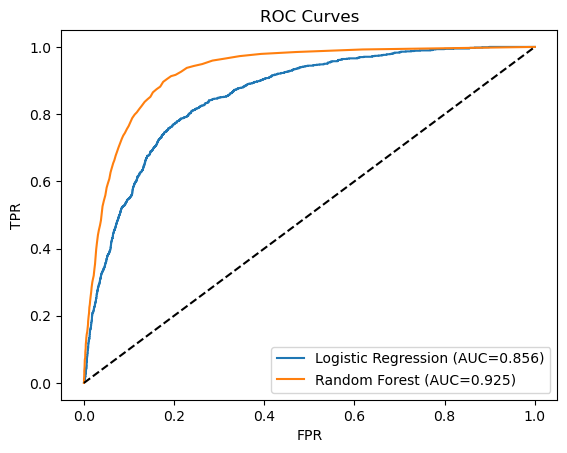

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [1]:
# task1_bank_marketing.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, classification_report
import shap

# 1. Load & Explore
df = pd.read_csv('bank-full.csv', sep=';')
print(df.head(), df.info(), df.describe())
print("\nClass Distribution:\n", df['y'].value_counts())

# 2. Encode Categoricals
cat_cols = df.select_dtypes(include='object').columns.drop('y')
le = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(lambda col: le.fit_transform(col))
df['y'] = (df['y'] == 'yes').astype(int)

X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Models
lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} Evaluation:")
    print(classification_report(y_test, y_pred))
    print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves'); plt.legend(); plt.show()

# 4. SHAP Explainability (Random Forest)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.iloc[:5])
shap.summary_plot(shap_values[1], X_test.iloc[:5], plot_type="bar")
for i in range(5):
    shap.force_plot(explainer.expected_value[1], shap_values[1][i], X_test.iloc[i], matplotlib=True)